# Libraries

In [1]:
import sys
import cv2
import torch
from matplotlib import pyplot as plt
import torch
# from efficientnet_pytorch import EfficientNet
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from torch import nn, optim
import numpy as np
import os
import argparse
from tqdm import tqdm
from sklearn.model_selection import train_test_split  
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import re

from PIL import Image
from torch.nn import functional as F

import cv2
import torch
import os
from tqdm import tqdm
import ptlflow
from ptlflow.utils import flow_utils
import re
import numpy as np
import concurrent.futures
import timm
import time 
import random
from torch.amp import autocast, GradScaler


from ptlflow.utils.io_adapter import IOAdapter

def set_seed(seed=42):
    # Python built-in random module
    random.seed(seed)
    
    # Environment variable for hash-based operations
    os.environ['PYTHONHASHSEED'] = str(seed)
    
    # NumPy random generator
    np.random.seed(seed)
    
    # PyTorch random generators
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed) # For multi-GPU setups
        
    # CuDNN determinism (Note: This might slightly impact performance)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Apply the seed
set_seed(1)

d:\D-Documents\Self-Improvement\Python\Computer_Vision\Speed Estimation\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
d:\D-Documents\Self-Improvement\Python\Computer_Vision\Speed Estimation\venv\Lib\site-packages\timm\models\layers\__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


[!!alt_cuda_corr is not compiled!!]


# Load Frames

In [2]:

frames_dir = r'D:\D-Documents\Self-Improvement\Python\Computer_Vision\Speed Estimation\Speed_Estimation_Cleaned\Dataset\Processed\Train\frames\\'

frames = os.listdir(frames_dir)
print(f"Total frames: {len(frames)}")


Total frames: 9135


In [3]:

def natural_sort_key(s):
    return int(re.search(r'(\d+)', s).group())

frames = sorted(os.listdir(frames_dir), key=natural_sort_key)

# Check actual frame count
print(f"Total frames: {len(frames)}")
print(f"First frame: {frames[0]}")
print(f"Last frame: {frames[-1]}")
print(f"Expected last frame: frame_{len(frames)-1}.jpg")
print(frames[:20])


Total frames: 9135
First frame: frame_0.png
Last frame: frame_9134.png
Expected last frame: frame_9134.jpg
['frame_0.png', 'frame_1.png', 'frame_2.png', 'frame_3.png', 'frame_4.png', 'frame_5.png', 'frame_6.png', 'frame_7.png', 'frame_8.png', 'frame_9.png', 'frame_10.png', 'frame_11.png', 'frame_12.png', 'frame_13.png', 'frame_14.png', 'frame_15.png', 'frame_16.png', 'frame_17.png', 'frame_18.png', 'frame_19.png']


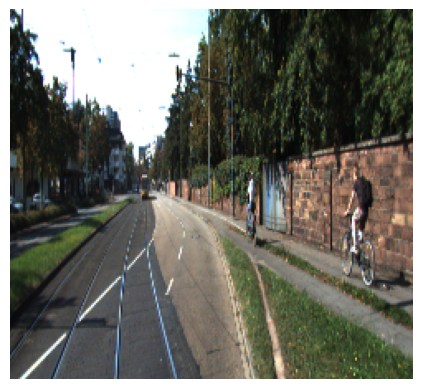

In [4]:
img = cv2.imread(os.path.join(frames_dir, frames[0]))
img = cv2.resize(img, (244, 224))   
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

# Get Flow

In [5]:

# 1. Stop clipping bright regions
def preprocess_small(img):
    # Simply return the un-clipped image so DPFlow can track textures accurately
    return img

def save_flow(flow_rgb, flow_filename):
    flow_rgb = cv2.resize(flow_rgb, (224, 224))
    plt.imsave(flow_filename, flow_rgb)

model_name = r'dpflow'
flows_dir_base = f'D:/D-Documents/Self-Improvement/Python/Computer_Vision/Speed Estimation/Speed_Estimation_Cleaned/Dataset/Ablation_Studies/{model_name}/'
curr_dir_base = f"D:/D-Documents/Self-Improvement/Python/Computer_Vision/Speed Estimation/Speed_Estimation_FYP_Cleaned/DPFlow_Modular_for_Lucentra/Ablation_Studies/{model_name}/"

In [6]:


device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = ptlflow.get_model(model_name.lower(), ckpt_path='kitti').to(device)
model.eval()

max_val, min_val = 255.0, 0.0  

frames_dir = r'D:\D-Documents\Self-Improvement\Python\Computer_Vision\Speed Estimation\Speed_Estimation_Cleaned\Dataset\Processed\Train\frames'
flows_dir = os.path.join(flows_dir_base, 'Train', 'flows_process_then_resize')
separate_frames_indices = r'D:\D-Documents\Self-Improvement\Python\Computer_Vision\Speed Estimation\Speed_Estimation_Cleaned\Dataset\Processed\Train\video_separation_indices.txt'
os.makedirs(flows_dir, exist_ok=True)

with open(separate_frames_indices, 'r') as f:
    line_indices = [int(line.strip()) for line in f.readlines()]

frames = sorted(os.listdir(frames_dir), key=natural_sort_key)

with concurrent.futures.ThreadPoolExecutor(max_workers=4) as executor:
    for i in tqdm(range(len(frames) - 1), desc="Optical Flow"):
        if i+1 in line_indices:
            continue

        img1_path = os.path.join(frames_dir, frames[i])
        img2_path = os.path.join(frames_dir, frames[i+1])
        img1 = cv2.imread(img1_path)
        img2 = cv2.imread(img2_path)
        
        if img1 is None or img2 is None:
            continue

        img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
        img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)
        
        img1 = preprocess_small(img1)
        img2 = preprocess_small(img2)

        # IOAdapter scales dynamically
        io_adapter = IOAdapter(model, img1.shape[:2])
        inputs = io_adapter.prepare_inputs([img1, img2])
        
        # Safely move the prepared inputs to your GPU/CPU
        inputs = {k: v.to(device) for k, v in inputs.items()}

        with torch.no_grad():
            pred = model(inputs)
            
        # Unpad the prediction so it matches your original image dimensions
        pred = io_adapter.unscale(pred)
        
        # pred['flows'] shape is [B, N_preds, 2, H, W]
        flow = pred['flows'][0, 0].cpu() # Shape: [2, H, W]
        
        # 2. KEY FIX CATCH: Clamp extreme vectors!
        # DPFlow computes very precise anomalies that squash `flow_to_rgb` scaling.
        # Clamping prevents the colormap from getting destroyed by a single bad pixel.
        flow = torch.clamp(flow, min=-150.0, max=150.0)
        
        # Normalized Flow using standard RGB as requested
        flow_rgb = flow_utils.flow_to_rgb(flow, background='dark').permute(1, 2, 0).numpy()

        flow_filename = os.path.join(flows_dir, f'flow_{i}.png')
        executor.submit(save_flow, flow_rgb, flow_filename)

        # Free up memory
        del inputs, pred, flow, flow_rgb
        torch.cuda.empty_cache()


2026-04-02 14:30:48.533 | INFO     | ptlflow.models.dpflow.dpflow:__init__:158 - DPFlow: --model.pyramid_levels is not set, the number of pyramid levels will be inferred from the input size.
2026-04-02 14:30:48.804 | INFO     | ptlflow:restore_model:283 - Restored model state from checkpoint: kitti
Optical Flow: 100%|██████████| 9134/9134 [27:41<00:00,  5.50it/s]


In [7]:


device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = ptlflow.get_model(model_name.lower(), ckpt_path='kitti').to(device)
model.eval()

max_val, min_val = 255.0, 0.0  

frames_dir = r'D:\D-Documents\Self-Improvement\Python\Computer_Vision\Speed Estimation\Speed_Estimation_Cleaned\Dataset\Processed\Val\frames'
flows_dir = os.path.join(flows_dir_base, 'Val', 'flows_process_then_resize')
separate_frames_indices = r'D:\D-Documents\Self-Improvement\Python\Computer_Vision\Speed Estimation\Speed_Estimation_Cleaned\Dataset\Processed\Val\video_separation_indices.txt'
os.makedirs(flows_dir, exist_ok=True)

with open(separate_frames_indices, 'r') as f:
    line_indices = [int(line.strip()) for line in f.readlines()]

frames = sorted(os.listdir(frames_dir), key=natural_sort_key)

with concurrent.futures.ThreadPoolExecutor(max_workers=4) as executor:
    for i in tqdm(range(len(frames) - 1), desc="Optical Flow"):
        if i+1 in line_indices:
            continue

        img1_path = os.path.join(frames_dir, frames[i])
        img2_path = os.path.join(frames_dir, frames[i+1])
        img1 = cv2.imread(img1_path)
        img2 = cv2.imread(img2_path)
        
        if img1 is None or img2 is None:
            continue

        img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
        img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)
        
        img1 = preprocess_small(img1)
        img2 = preprocess_small(img2)

        # IOAdapter scales dynamically
        io_adapter = IOAdapter(model, img1.shape[:2])
        inputs = io_adapter.prepare_inputs([img1, img2])
        
        # Safely move the prepared inputs to your GPU/CPU
        inputs = {k: v.to(device) for k, v in inputs.items()}

        with torch.no_grad():
            pred = model(inputs)
            
        # Unpad the prediction so it matches your original image dimensions
        pred = io_adapter.unscale(pred)
        
        # pred['flows'] shape is [B, N_preds, 2, H, W]
        flow = pred['flows'][0, 0].cpu() # Shape: [2, H, W]
        
        # 2. KEY FIX CATCH: Clamp extreme vectors!
        # DPFlow computes very precise anomalies that squash `flow_to_rgb` scaling.
        # Clamping prevents the colormap from getting destroyed by a single bad pixel.
        flow = torch.clamp(flow, min=-150.0, max=150.0)
        
        # Normalized Flow using standard RGB as requested
        flow_rgb = flow_utils.flow_to_rgb(flow, background='dark').permute(1, 2, 0).numpy()

        flow_filename = os.path.join(flows_dir, f'flow_{i}.png')
        executor.submit(save_flow, flow_rgb, flow_filename)

        # Free up memory
        del inputs, pred, flow, flow_rgb
        torch.cuda.empty_cache()


2026-04-02 14:58:30.316 | INFO     | ptlflow.models.dpflow.dpflow:__init__:158 - DPFlow: --model.pyramid_levels is not set, the number of pyramid levels will be inferred from the input size.
2026-04-02 14:58:30.478 | INFO     | ptlflow:restore_model:283 - Restored model state from checkpoint: kitti
Optical Flow: 100%|██████████| 2123/2123 [06:23<00:00,  5.53it/s]


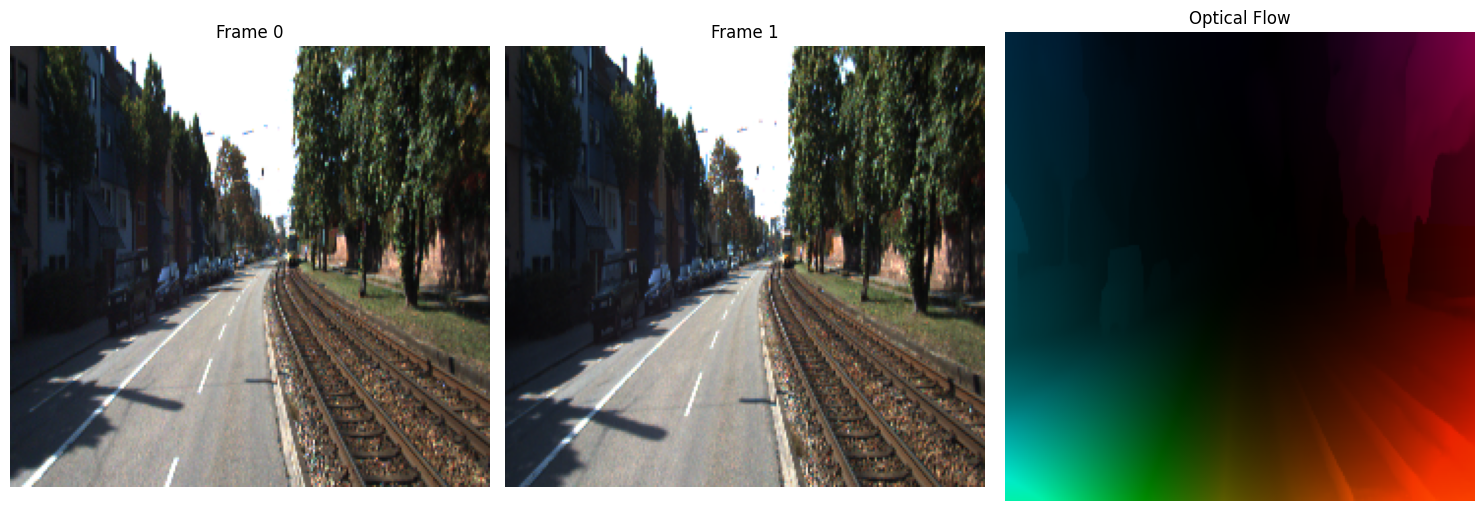

In [8]:
idx = 2

frame_img1 = cv2.imread(os.path.join(frames_dir, frames[idx]))
frame_img2 = cv2.imread(os.path.join(frames_dir, frames[idx+1]))
flow_img = plt.imread(os.path.join(flows_dir, f'flow_{idx}.png'))  # Loads as RGB

# Crop and resize frames
# frame_img1 = frame_img1[frame_img1.shape[0]//2 - 200: -200, :, :]
frame_img1 = cv2.resize(frame_img1, (244, 224))
frame_img1_rgb = cv2.cvtColor(frame_img1, cv2.COLOR_BGR2RGB)

# frame_img2 = frame_img2[frame_img2.shape[0]//2 - 200: -200, :, :]
frame_img2 = cv2.resize(frame_img2, (244, 224))
frame_img2_rgb = cv2.cvtColor(frame_img2, cv2.COLOR_BGR2RGB)

fig, axs = plt.subplots(1, 3, figsize=(15, 5))
axs[0].imshow(frame_img1_rgb)
axs[0].set_title('Frame 0')
axs[0].axis('off')
axs[1].imshow(frame_img2_rgb)
axs[1].set_title('Frame 1')
axs[1].axis('off')
axs[2].imshow(flow_img)
axs[2].set_title('Optical Flow')
axs[2].axis('off')
plt.tight_layout()

# Train Test Split

In [6]:
def create__indices(folder, random_state=42):
    image_files = [f for f in os.listdir(folder) if f.startswith('flow_') and f.endswith('.png')]
    indices = [int(f.split('_')[1].split('.')[0]) for f in image_files]
    
    # indices = sorted(indices)
    # missing = [i for i in range(indices[0], indices[-1]+1) if i not in indices]
    # print(missing)

    random.seed(random_state)
    random.shuffle(indices)
    return indices


train_indices = create__indices(os.path.join(flows_dir_base, 'Train', 'flows_process_then_resize'), random_state=42)
val_indices =   create__indices(os.path.join(flows_dir_base, 'Val', 'flows_process_then_resize'), random_state=42)

print(f"\nTrain indices: {train_indices[:10]} ... Total: {len(train_indices)}")
print(f"Val indices: {val_indices[:10]} ... Total: {len(val_indices)}")



Train indices: [100, 4997, 5355, 2043, 2690, 6837, 4421, 1476, 7513, 7317] ... Total: 9106
Val indices: [585, 136, 733, 159, 1797, 266, 928, 781, 868, 1503] ... Total: 2120


In [7]:
os.path.join(flows_dir_base, 'Train', 'flows_process_then_resize')

'D:/D-Documents/Self-Improvement/Python/Computer_Vision/Speed Estimation/Speed_Estimation_Cleaned/Dataset/Ablation_Studies/dpflow/Train\\flows_process_then_resize'

# Dataloader

In [8]:

class PreprocessedSpeedDataset(Dataset):
    def __init__(self, folder, speed_file, indices=None, transform=None):
        self.folder = folder
        self.transform = transform  

        if indices:
            self.flow_files = [os.path.join(folder, f'flow_{idx}.png') for idx in indices]
        else:
            self.flow_files = [os.path.join(folder, f'flow_{idx}.png') for idx in range(len(os.listdir(folder)))]

        all_speeds = [float(speed) for speed in open(speed_file).read().splitlines()]
        self.speed_files = [all_speeds[idx+1] for idx in indices] if indices else all_speeds
        
    
    def __len__(self):
        return len(self.flow_files)
    
    def __getitem__(self, idx):
        image = plt.imread(self.flow_files[idx])[:, :, :3]  # Ensure RGB format

        speed = self.speed_files[idx]
        speed = torch.tensor(speed, dtype=torch.float32)

        if self.transform:
            image = self.transform(image)
        else:
            image = transforms.ToTensor()(image)

        return image, speed



transform = transforms.Compose([
    transforms.ToTensor(),
    # transforms.Resize((224, 224)),
])



In [9]:

train_flow_dir = os.path.join(flows_dir_base, 'Train', 'flows_process_then_resize')
val_flow_dir =   os.path.join(flows_dir_base, 'Val', 'flows_process_then_resize')

train_speed_dir = r"D:\D-Documents\Self-Improvement\Python\Computer_Vision\Speed Estimation\Speed_Estimation_Cleaned\Dataset\Processed\Train\frame_speeds.txt"
val_speed_dir =   r"D:\D-Documents\Self-Improvement\Python\Computer_Vision\Speed Estimation\Speed_Estimation_Cleaned\Dataset\Processed\Val\frame_speeds.txt"

train_dataset = PreprocessedSpeedDataset(train_flow_dir, train_speed_dir, train_indices, transform=transform)
val_dataset = PreprocessedSpeedDataset(val_flow_dir, val_speed_dir, val_indices, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, num_workers=0, shuffle=True, pin_memory=True)   # * 64 best, 32 2nd best
val_loader = DataLoader(val_dataset, batch_size=32, num_workers=0, pin_memory=True)


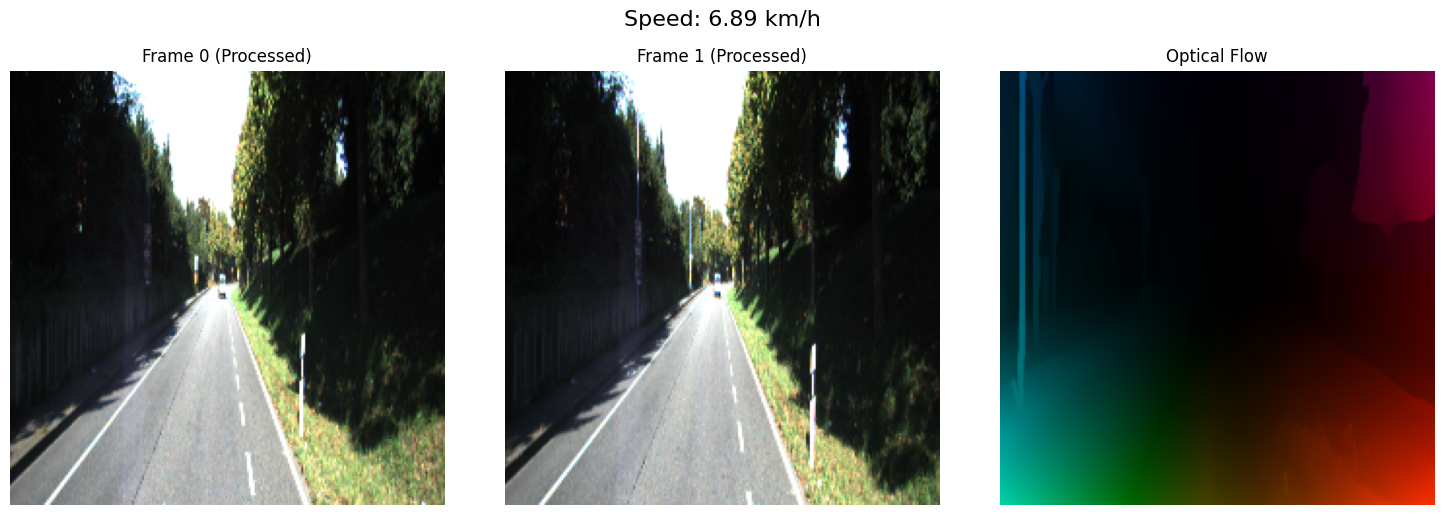

Speed value: 6.89
Flow image shape: (224, 224, 3)
Dataset returns: image tensor of shape torch.Size([3, 224, 224]), speed value 6.887383460998535


In [13]:
idx = 200
# idx = 0

# Create subplots to display frame0, frame1, flow, and speed
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

# Load and display frame0
frame0_path = os.path.join(frames_dir, frames[idx])
frame0 = cv2.imread(frame0_path)
frame0_rgb = cv2.cvtColor(frame0, cv2.COLOR_BGR2RGB)
frame0 = cv2.resize(frame0, (224, 224))
frame0_processed_rgb = cv2.cvtColor(frame0, cv2.COLOR_BGR2RGB)

axs[0].imshow(frame0_processed_rgb)
axs[0].set_title('Frame 0 (Processed)')
axs[0].axis('off')

# Load and display frame1
frame1_path = os.path.join(frames_dir, frames[idx + 1])
frame1 = cv2.imread(frame1_path)
frame1 = cv2.resize(frame1, (224, 224))
frame1_processed_rgb = cv2.cvtColor(frame1, cv2.COLOR_BGR2RGB)

axs[1].imshow(frame1_processed_rgb)
axs[1].set_title('Frame 1 (Processed)')
axs[1].axis('off')

# Display optical flow from dataset
flow_image = train_dataset[idx][0].permute(1, 2, 0).numpy()
axs[2].imshow(flow_image)
axs[2].set_title('Optical Flow')
axs[2].axis('off')

# Get speed value from dataset
speed_value = train_dataset[idx][1].item()
fig.suptitle(f'Speed: {speed_value:.2f} km/h', fontsize=16, y=1.02)

plt.tight_layout()
plt.show()

print(f"Speed value: {speed_value:.2f}")
print(f"Flow image shape: {flow_image.shape}")
print(f"Dataset returns: image tensor of shape {train_dataset[idx][0].shape}, speed value {speed_value}")

# Train Model

In [10]:

class EfficientNetV2TinyModel(nn.Module):
    def __init__(self, pretrained=True, dropout_rate=0.1):
        super(EfficientNetV2TinyModel, self).__init__()
        
        self.base_model = timm.create_model('efficientnetv2_rw_t', pretrained=pretrained, num_classes=0)  # * Best

        num_features = self.base_model.num_features
        
        # Simpler head for tiny model
        self.head = nn.Sequential(
            nn.Dropout(dropout_rate),
            nn.Linear(num_features, 1),
        )
        
    def forward(self, x):
        features = self.base_model(x)
        output = self.head(features)
        return output
    
    
def validate(model, val_loader, criterion, device):
    model.eval()
    total_loss = 0.0
    n = 0
    with torch.no_grad():
        for images, speeds in val_loader:
            images = images.to(device)
            speeds = speeds.to(device)  
            
            # use autocast for inference if using AMP
            with autocast('cuda'):
                outputs = model(images)
                loss = criterion(outputs.squeeze(), speeds)

            total_loss += loss.item() * images.size(0)
            n += images.size(0)

    avg_loss = total_loss / n
    return avg_loss


In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = EfficientNetV2TinyModel(pretrained=True, dropout_rate=0.2).to(device)   # dropout 0.2 is best
criterion = nn.MSELoss()
# criterion = nn.L1Loss() # MAE Loss
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)
# Scheduelr
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10, eta_min=0.00001)

print(f"Model: {model.__class__.__name__}")
print(f"Parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Model: EfficientNetV2TinyModel
Parameters: 12,625,413


# Training Loop

In [12]:

# ! LR Scheduler + Mixed Precision Training
# Import mixed precision training - Updated API

num_epochs = 25
best_loss = float('inf')

# Training with scheduler and mixed precision
scaler = GradScaler()  # Updated API
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-6)

start_time = time.time()
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0  
    pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}', leave=True)

    for batch_idx, (images, speeds) in enumerate(pbar):
        images = images.to(device)
        speeds = speeds.to(device)
        
        optimizer.zero_grad()
        
        # Mixed precision forward pass - Updated API
        with autocast('cuda'):
            outputs = model(images)
            loss = criterion(outputs.squeeze(), speeds)

        # Scale loss and backward pass
        scaler.scale(loss).backward()
        
        # Gradient clipping for stability
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        # Update parameters
        scaler.step(optimizer)
        scaler.update()
        
        running_loss += loss.item()
        pbar.set_postfix({
            'Loss': f'{loss.item():.6f}',
            'LR': f'{optimizer.param_groups[0]["lr"]:.2e}'
        })
        
        # Clear cache periodically
        if batch_idx % 20 == 0:
            torch.cuda.empty_cache()


    avg_loss = running_loss / len(train_loader)
    
    # Step scheduler
    scheduler.step()

    # Validate at the end of each epoch
    val_loss = validate(model, val_loader, criterion, device)

    # Save best model
    if val_loss < best_loss:
        best_loss = val_loss
        torch.save(model.state_dict(), os.path.join(curr_dir_base, 'weights', 'best_model_3.pth'))
        print(f"New best model saved with loss: {val_loss:.6f}")

    print(f'\nEpoch {epoch+1}/{num_epochs}, Train Average Loss: {avg_loss:.6f}, Val Average Loss: {val_loss:.6f}, Val RMSE Loss: {np.sqrt(val_loss):.6f}, LR: {optimizer.param_groups[0]["lr"]:.2e}\n')

    # Clear cache after each epoch
    torch.cuda.empty_cache()

print(f"Training completed! Best loss: {best_loss:.6f}")
# End timing
end_time = time.time()
elapsed_time = end_time - start_time

print(f"Training completed in {elapsed_time:.2f} seconds")
print(f"Training completed in {elapsed_time/60:.2f} minutes")


Epoch 1/25: 100%|██████████| 143/143 [00:22<00:00,  6.48it/s, Loss=0.475127, LR=1.00e-03]


New best model saved with loss: 1.957409

Epoch 1/25, Train Average Loss: 9.239418, Val Average Loss: 1.957409, Val RMSE Loss: 1.399074, LR: 9.96e-04



Epoch 2/25: 100%|██████████| 143/143 [00:20<00:00,  6.99it/s, Loss=1.265357, LR=9.96e-04]


New best model saved with loss: 1.491639

Epoch 2/25, Train Average Loss: 1.079299, Val Average Loss: 1.491639, Val RMSE Loss: 1.221327, LR: 9.84e-04



Epoch 3/25: 100%|██████████| 143/143 [00:20<00:00,  7.03it/s, Loss=0.602839, LR=9.84e-04]


...


Epoch 23/25, Train Average Loss: 0.035461, Val Average Loss: 1.157829, Val RMSE Loss: 1.076025, LR: 1.67e-05



Epoch 24/25: 100%|██████████| 143/143 [00:21<00:00,  6.78it/s, Loss=0.018051, LR=1.67e-05]



Epoch 24/25, Train Average Loss: 0.036674, Val Average Loss: 1.148571, Val RMSE Loss: 1.071714, LR: 4.94e-06



Epoch 25/25: 100%|██████████| 143/143 [00:20<00:00,  6.82it/s, Loss=0.805872, LR=4.94e-06]



Epoch 25/25, Train Average Loss: 0.040443, Val Average Loss: 1.155567, Val RMSE Loss: 1.074973, LR: 1.00e-06

Training completed! Best loss: 0.858118
Training completed in 583.88 seconds
Training completed in 9.73 minutes


# Evaluate

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = EfficientNetV2TinyModel(pretrained=False, dropout_rate=0.2).to(device)   # Set pretrained=False when loading weights

# Load the trained weights
model_path = os.path.join(curr_dir_base, 'weights', 'best_model_3.pth')
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()  # Set to evaluation mode

criterion = nn.L1Loss()
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10, eta_min=0.00001)

print(f"Model: {model.__class__.__name__}")
print(f"Parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print(f"Loaded weights from: {model_path}")

Model: EfficientNetV2TinyModel
Parameters: 12,625,413
Loaded weights from: D:/D-Documents/Self-Improvement/Python/Computer_Vision/Speed Estimation/Speed_Estimation_FYP_Cleaned/DPFlow_Modular_for_Lucentra/Ablation_Studies/dpflow/weights\best_model_3.pth


In [15]:
criterion = nn.L1Loss()
mae_loss = validate(model, val_loader, criterion, device)
print(f'Validation MAE Loss: {mae_loss:.6f}')
criterion = nn.MSELoss()
mse_loss = validate(model, val_loader, criterion, device)
rmse_loss = np.sqrt(mse_loss)
print(f'Validation RMSE Loss: {rmse_loss:.6f}')
print(f'Validation MSE Loss: {mse_loss:.6f}')


Validation MAE Loss: 0.579341
Validation RMSE Loss: 0.926347
Validation MSE Loss: 0.858118


In [ ]:
Validation MAE Loss: 0.587689
Validation RMSE Loss: 0.994072
Validation MSE Loss: 0.988180

In [ ]:

# Define the results file path
import csv
import time

results_file = os.path.join(curr_dir_base, r'..\evaluation_results.csv')

# Measure inference time for 10 data elements
model.eval()
times = []
with torch.no_grad():
    for i in range(10):
        img, _ = val_dataset[i]
        img = img.unsqueeze(0).to(device)
        start = time.time()
        _ = model(img)
        end = time.time()
        times.append(end - start)
avg_inference_time = sum(times) / len(times)
print(f'Average inference time for 10 elements: {avg_inference_time:.4f} seconds')

# Check if file exists, if not, write header
if not os.path.exists(results_file):
    with open(results_file, 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(['Model', 'MAE Loss', 'RMSE Loss', 'MSE Loss', 'Inference Time (s)'])

# Append the results
with open(results_file, 'a', newline='') as f:
    writer = csv.writer(f)
    writer.writerow([model_name, f"{mae_loss:.2f}", f"{rmse_loss:.2f}", f"{mse_loss:.2f}", f"{avg_inference_time:.4f}"])

print(f"Results saved to {results_file}")

Average inference time for 10 elements: 0.0105 seconds
Results saved to D:/D-Documents/Self-Improvement/Python/Computer_Vision/Speed Estimation/Speed_Estimation_FYP_Cleaned/DPFlow_Modular_for_Lucentra/Ablation_Studies/dpflow/..\evaluation_results.csv


In [ ]:
def any_nan(model, loader, device):
    model.eval()
    with torch.no_grad():
        for imgs, ys in loader:
            imgs = imgs.to(device)
            ys = ys.to(device)
            outs = model(imgs)
            if torch.isnan(outs).any() or torch.isnan(ys).any():
                return True
    return False

print("NaNs in val?", any_nan(model, val_loader, device))


NaNs in val? False


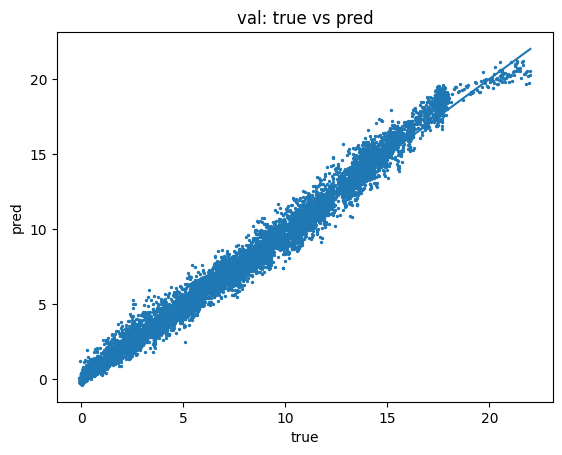

In [ ]:
import matplotlib.pyplot as plt
model.eval()
ys_all, preds_all = [], []
with torch.no_grad():
    for imgs, ys in train_loader:
        imgs = imgs.to(device)
        outs = model(imgs).view(-1).cpu().numpy()
        preds_all.append(outs)
        ys_all.append(ys.view(-1).numpy())
preds = np.concatenate(preds_all)
ys = np.concatenate(ys_all)

# scatter (put in a .py, will open a window or save fig)
plt.scatter(ys, preds, s=2)
plt.xlabel("true")
plt.ylabel("pred")
plt.title("val: true vs pred")
plt.plot([ys.min(), ys.max()], [ys.min(), ys.max()])
plt.savefig("val_scatter.png", dpi=200)


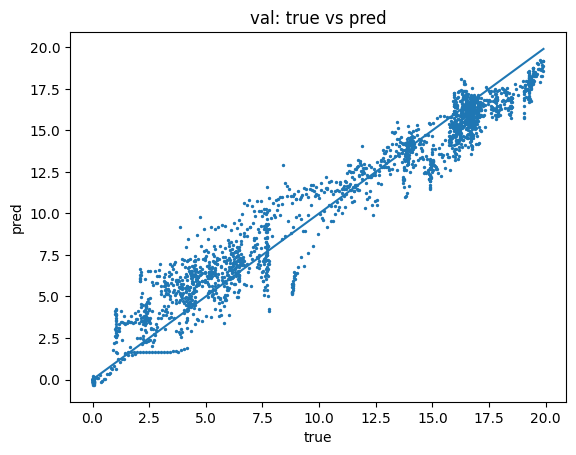

In [ ]:
import matplotlib.pyplot as plt
model.eval()
ys_all, preds_all = [], []
with torch.no_grad():
    for imgs, ys in val_loader:
        imgs = imgs.to(device)
        outs = model(imgs).view(-1).cpu().numpy()
        preds_all.append(outs)
        ys_all.append(ys.view(-1).numpy())
preds = np.concatenate(preds_all)
ys = np.concatenate(ys_all)

# scatter (put in a .py, will open a window or save fig)
plt.scatter(ys, preds, s=2)
plt.xlabel("true")
plt.ylabel("pred")
plt.title("val: true vs pred")
plt.plot([ys.min(), ys.max()], [ys.min(), ys.max()])
plt.savefig("val_scatter.png", dpi=200)


In [ ]:
def val_batch_stats(model, loader, criterion, device):
    model.eval()
    batch_losses = []
    with torch.no_grad():
        for imgs, ys in loader:
            imgs = imgs.to(device)
            ys = ys.view(-1).float().to(device)
            outs = model(imgs).view(-1)
            batch_loss = ((outs - ys)**2).mean().item()   # batch MSE
            batch_losses.append(batch_loss)
    import numpy as np
    return np.mean(batch_losses), np.std(batch_losses), np.max(batch_losses), np.percentile(batch_losses, 90)

print("batch mean, std, max, 90p:", val_batch_stats(model, val_loader, criterion, device))


batch mean, std, max, 90p: (np.float64(2.109592549836458), np.float64(0.5349243936582518), np.float64(3.561140537261963), np.float64(2.8430812835693358))


In [ ]:
import numpy as np

def label_stats(loader):
    ys = []
    for _, y in loader:
        ys.append(y.view(-1).numpy())
    ys = np.concatenate(ys)
    return {
        'mean': ys.mean(), 'std': ys.std(),
        'min': ys.min(), 'max': ys.max(),
        'p10': np.percentile(ys,10), 'p50': np.percentile(ys,50), 'p90': np.percentile(ys,90)
    }

print("Train labels:", label_stats(train_loader))
print("Val   labels:", label_stats(val_loader))


Train labels: {'mean': np.float32(8.078087), 'std': np.float32(5.4035563), 'min': np.float32(-0.097603306), 'max': np.float32(22.009907), 'p10': np.float32(0.5352056), 'p50': np.float32(7.9205303), 'p90': np.float32(15.348415)}
Val   labels: {'mean': np.float32(10.828528), 'std': np.float32(6.074147), 'min': np.float32(0.0026199452), 'max': np.float32(19.903751), 'p10': np.float32(2.3781836), 'p50': np.float32(12.386826), 'p90': np.float32(17.330305)}
